In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

In [5]:
df = pd.read_pickle("phase2_low_confidence_sections.pkl")
one_hot_classifications = pd.get_dummies(df.classification)
df = pd.concat([df, one_hot_classifications], axis=1)
df


,seed,bitstring,biological_energy,energy_diff,protein,residues,residue_count,rotamers,num_qubits,classification,loss,tie,win
0,0,"(1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0)",147.286634,-5.636862,AF-5PTI,13_20,8,3,13,win,False,False,True
1,1,"(1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0)",147.286634,-5.636862,AF-5PTI,13_20,8,3,13,win,False,False,True
2,2,"(1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0)",147.286634,-5.636862,AF-5PTI,13_20,8,3,13,win,False,False,True
3,3,"(1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0)",147.563544,-5.359952,AF-5PTI,13_20,8,3,13,win,False,False,True
4,4,"(1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0)",147.286634,-5.636862,AF-5PTI,13_20,8,3,13,win,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,25,"(1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0)",136.946729,-15.976767,AF-5PTI,4_7,4,3,12,win,False,False,True
1496,26,"(1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0)",136.946729,-15.976767,AF-5PTI,4_7,4,3,12,win,False,False,True
1497,27,"(1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0)",136.966413,-15.957083,AF-5PTI,4_7,4,3,12,win,False,False,True
1498,28,"(1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0)",136.946729,-15.976767,AF-5PTI,4_7,4,3,12,win,False,False,True


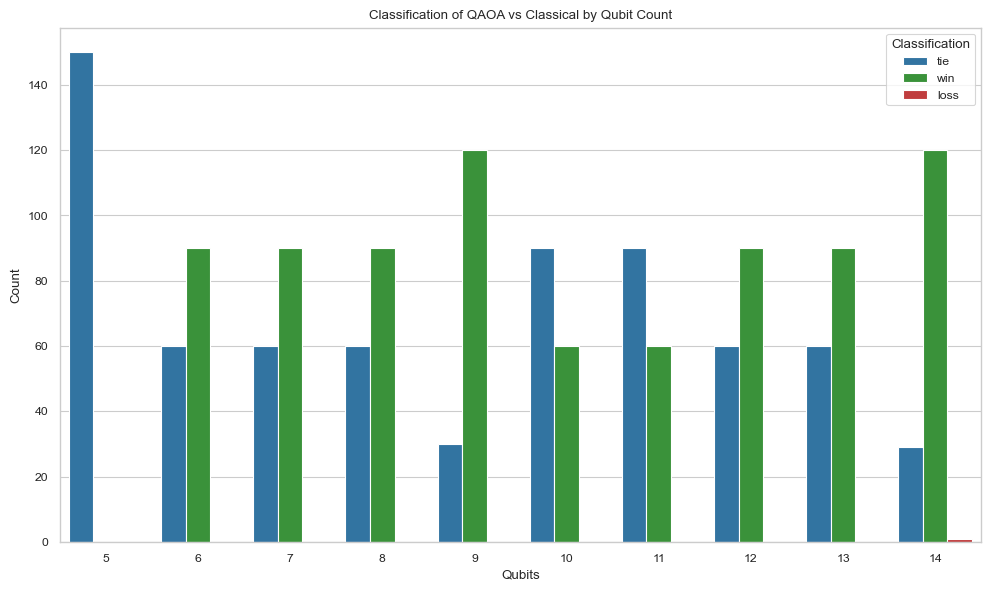

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="num_qubits", hue="classification", palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"})
plt.xlabel("Qubits")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Qubit Count")
plt.legend(title="Classification")
plt.tight_layout()
# plt.savefig("../plots/classification_counts_5_10_qubits.svg", dpi=300, bbox_inches="tight")
plt.show()

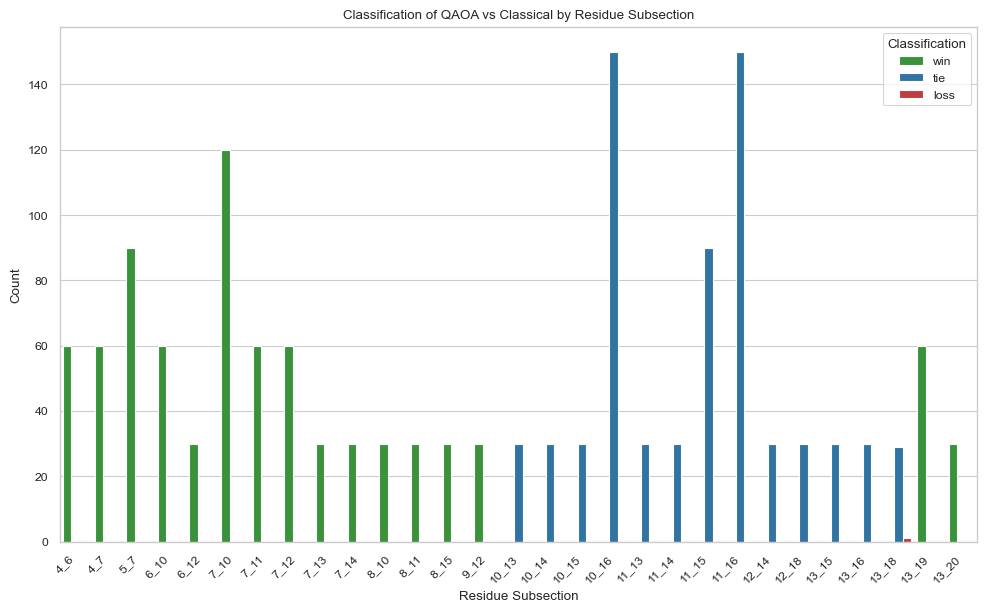

In [14]:
residue_order = (
    df["residues"]
    .dropna()
    .unique()
)

residue_order = sorted(
    residue_order,
    key=lambda s: tuple(map(int, s.split("_")))  # e.g. "18_24" -> (18, 24)
)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="residues",
    hue="classification",
    order=residue_order,
    palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"},
)
plt.xlabel("Residue Subsection")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Residue Subsection")
plt.legend(title="Classification")
plt.tight_layout()

# rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

plt.savefig("../plots/classification_counts_moderate_confidence.svg", dpi=300, bbox_inches="tight")

plt.show()

In [7]:
df.classification.describe()

count     1500
unique       3
top        win
freq       810
Name: classification, dtype: object

In [9]:
df.groupby("classification").energy_diff.describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
loss,1.0,1.875775,NaN,1.875775,1.875775,1.875775,1.875775,1.875775
tie,689.0,-0.278521,0.4948,-0.696033,-0.638771,-0.336763,-0.245702,1.444296
win,810.0,-8.114499,5.4848,-16.265277,-15.210243,-4.389259,-3.353218,-2.983119


In [11]:
df.to_pickle("phase2_low_confidence_sections.pkl")

In [11]:
residue_order = (
    df["residues"]
    .dropna()
    .unique()
)

residue_order = sorted(
    residue_order,
    key=lambda s: tuple(map(int, s.split("_")))  # e.g. "18_24" -> (18, 24)
)

df['residues'] = pd.Categorical(df['residues'], residue_order)

df.groupby("residues").agg({"win": "sum", "loss": "sum", "tie": "sum", "energy_diff": "min"})


,win,loss,tie,energy_diff
residues,,,,
4_6,60,0,0,-15.659515
4_7,60,0,0,-15.976767
5_7,90,0,0,-13.925438
6_10,60,0,0,-15.263428
6_12,30,0,0,-16.265277
7_10,120,0,0,-3.335186
7_11,60,0,0,-3.353218
7_12,60,0,0,-4.389259
7_13,30,0,0,-4.288092


In [13]:
df.energy_diff.describe()

count    1500.000000
mean       -4.508513
std         5.623681
min       -16.265277
25%        -5.605991
50%        -3.156056
75%        -0.560441
max         1.875775
Name: energy_diff, dtype: float64